In [1]:
import os
import rasterio
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import rasterio
from pyproj import Transformer
import random


In [3]:
files_dir  = "../Data/Sat-Data/data_clip_exolabs"

#get all files in dir 
files = os.listdir(files_dir)
print(files)

#load tif 


tif_files = [] #LOAD all .tif 
for file in files:
    src = rasterio.open(os.path.join(files_dir, file))
    tif_files.append(src.read(1))


['2023-04-27+000_alps_HS_product.tif', '2023-04-19+000_alps_HS_product.tif', '2023-06-25+000_alps_HS_product.tif', '2023-05-06+000_alps_HS_product.tif', '2023-05-09+000_alps_HS_product.tif', '2023-06-14+000_alps_HS_product.tif', '2023-04-16+000_alps_HS_product.tif', '2023-04-28+000_alps_HS_product.tif', '2023-04-05+000_alps_HS_product.tif', '2023-06-07+000_alps_HS_product.tif', '2023-05-24+000_alps_HS_product.tif', '2023-05-15+000_alps_HS_product.tif', '2023-06-08+000_alps_HS_product.tif', '2023-06-10+000_alps_HS_product.tif', '2023-04-12+000_alps_HS_product.tif', '2023-04-23+000_alps_HS_product.tif', '2023-05-02+000_alps_HS_product.tif', '2023-06-21+000_alps_HS_product.tif', '2023-05-11+000_alps_HS_product.tif', '2023-04-30+000_alps_HS_product.tif', '2023-04-01+000_alps_HS_product.tif', '2023-05-20+000_alps_HS_product.tif', '2023-06-03+000_alps_HS_product.tif', '2023-05-12+000_alps_HS_product.tif', '2023-04-02+000_alps_HS_product.tif', '2023-05-23+000_alps_HS_product.tif', '2023-06-13

In [6]:
###EXPLORING THE FORMAT OF COORDINATE SYSTEM
with rasterio.open('../Data/Sat-Data/data_clip_exolabs/2023-04-01+000_alps_HS_product.tif') as src:
    # Check metadata
    print(src.crs)  # Coordinate Reference System (CRS)
    print(src.bounds)  # Bounding box (min, max) coordinates
    print(src.transform)

EPSG:3857
BoundingBox(left=829059.4892686082, bottom=5860743.433705239, right=938039.4892686082, top=5927163.433705239)
| 20.00, 0.00, 829059.49|
| 0.00,-20.00, 5927163.43|
| 0.00, 0.00, 1.00|


In [8]:
###EXPLORE AVALANCHE DATA FROM SLF

avalanche_data = pd.read_csv('../Data/Sat-Data/data_SLF_avalanche.csv')
print(avalanche_data.head())
print(avalanche_data.columns)

                           avalanche_id                   location  \
0  f9d63b0f-4a9d-443d-9df5-30e8ba818ef2   POINT(9.80967 46.832453)   
1  216c2530-d139-11ed-80fa-f54d650c1715   POINT(7.74259 46.055277)   
2  d58cf800-d139-11ed-af01-234d49385de9  POINT(7.737122 46.047328)   
3  36855710-d13a-11ed-af01-234d49385de9  POINT(7.736374 46.053393)   
4  6ab88170-d157-11ed-991a-6bfa9504affb  POINT(8.936376 46.932609)   

               trigger_date_time  trigger_date_time_accuracy_code  \
0  2023-04-01 10:44:00.000 +0200                                1   
1  2023-04-02 10:05:00.000 +0200                                0   
2  2023-04-02 09:55:00.000 +0200                                0   
3  2023-04-02 09:54:00.000 +0200                                0   
4  2023-04-02 14:20:00.000 +0200                                0   

  trigger_type avalanche_type  avalanche_size avalanche_moisture  \
0       PERSON           SLAB               2                DRY   
1    EXPLOSIVE           SLA

In [9]:
avalanche_data['location']
#string POINT(9.80967 46.832453)  
#remove POINT( and )
avalanche_data['location'] = avalanche_data['location'].str.replace('POINT(', '').str.replace(')', '')
avalanche_data['lat'] = avalanche_data['location'].apply(lambda x: float(x.split(' ')[1]))
avalanche_data['lon'] = avalanche_data['location'].apply(lambda x: float(x.split(' ')[0]))
print(avalanche_data['lon'])

0       9.809670
1       7.742590
2       7.737122
3       7.736374
4       8.936376
          ...   
1691    8.971368
1692    7.045566
1693    7.797743
1694    7.747613
1695    7.745373
Name: lon, Length: 1696, dtype: float64


In [13]:
date = avalanche_data['trigger_date_time'][0].split(' ')[0]
date 
def tif_path_from_date(date):
    return f"../Data/Sat-Data/data_clip_exolabs/{date}+000_alps_HS_product.tif"

new_df = pd.DataFrame(columns=['avalanche_id', 'location', 'trigger_date_time',
       'trigger_date_time_accuracy_code', 'trigger_type', 'avalanche_type',
       'avalanche_size', 'avalanche_moisture', 'start_zone_aspect', 'snow_depth_sat'])

In [14]:
new_df.head()


,avalanche_id,location,trigger_date_time,trigger_date_time_accuracy_code,trigger_type,avalanche_type,avalanche_size,avalanche_moisture,start_zone_aspect,snow_depth_sat


In [15]:
###FILTER ONLY POINT IN BOUNDS OF SAT DATA -> EXPORT SNOW DEPTH FROM SATELITE




transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)


for _, row in avalanche_data.iterrows():
    date = row['trigger_date_time'].split(' ')[0]
    tif_path = tif_path_from_date(date)

    with rasterio.open(tif_path) as tif_map:
        bounds = tif_map.bounds
        lon = row['lon']
        lat = row['lat']
        x_3857, y_3857 = transformer.transform(lon, lat)

        if bounds.left <= x_3857 <= bounds.right and bounds.bottom <= y_3857 <= bounds.top:
                row_px, col_px = tif_map.index(x_3857, y_3857)
                snow_depth_sat = tif_map.read(1)[row_px, col_px]

                new_df = pd.concat([new_df, pd.DataFrame([row])], ignore_index=True)
                new_df.at[new_df.index[-1], 'snow_depth_sat'] = snow_depth_sat



In [146]:
#IMPUTE RANDOM POINTS 
#idea : for each point where there's avalanche , we take 10 random points within 1-5km spacial radius and 0-3 timestep and add them to the dataset
new_df["Avalanche Event"] = 1

# Create a new DataFrame to store the random points
random_points_df = pd.DataFrame(columns=new_df.columns)

for index, row in new_df.iterrows():
    # Generate 10 random points within a radius of 1-5km
    for _ in range(9):
       
        lat_offset = random.uniform(-0.045, 0.045)  # Approx. 5 km in degrees
        lon_offset = random.uniform(-0.045, 0.045)  # Approx. 5 km in degrees

        days_offset = random.randint(0, 3)

        # Create a new row with the random point
        random_row = row.copy()
        random_row['lat'] += lat_offset
        random_row['lon'] += lon_offset
        random_row['trigger_date_time'] = pd.to_datetime(row['trigger_date_time']) + pd.Timedelta(days=days_offset)
        random_row['Avalanche Event'] = 0

        # Append the random point to the new DataFrame
        random_points_df = pd.concat([random_points_df, pd.DataFrame([random_row])], ignore_index=True)

new_df = pd.concat([new_df, random_points_df], ignore_index=True)
# Shuffle the DataFrame
new_df = new_df.sample(frac=1).reset_index(drop=True)



/var/folders/lj/yyssz_p12f50nl5zkgxpqy5h0000gn/T/ipykernel_42352/3917566034.py:25: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  random_points_df = pd.concat([random_points_df, pd.DataFrame([random_row])], ignore_index=True)


In [16]:
#NOT A RANNDOM IMPUTATION 
#idea : learn time dependancy , the snow pack melts so we wanna know history of precise location 
new_df["Avalanche Event"] = 1

# Create a new DataFrame to store the random points
negative_past_avalanches = pd.DataFrame(columns=new_df.columns)

for index, row in new_df.iterrows():
    # Generate 10 random points within a radius of 1-5km
    for day in range(5):
       

        # Create a new row with the random point
        random_row = row.copy()

        random_row['trigger_date_time'] = pd.to_datetime(row['trigger_date_time']) + pd.Timedelta(days=day)
        random_row['Avalanche Event'] = 0

        # Append the random point to the new DataFrame
        negative_past_avalanches = pd.concat([negative_past_avalanches, pd.DataFrame([random_row])], ignore_index=True)

new_df = pd.concat([new_df, negative_past_avalanches], ignore_index=True)
# Shuffle the DataFrame
new_df = new_df.sample(frac=1).reset_index(drop=True)



/var/folders/lj/yyssz_p12f50nl5zkgxpqy5h0000gn/T/ipykernel_74669/3150969398.py:20: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  negative_past_avalanches = pd.concat([negative_past_avalanches, pd.DataFrame([random_row])], ignore_index=True)


In [17]:
new_df.head()

,avalanche_id,location,trigger_date_time,trigger_date_time_accuracy_code,trigger_type,avalanche_type,avalanche_size,avalanche_moisture,start_zone_aspect,snow_depth_sat,lat,lon,Avalanche Event
0,20077a30-ec16-11ed-aa20-6507e99101f4,8.022203 46.505884,2023-05-06 14:00:00.000 +0200,0,PERSON,SLAB,2,WET,E,90,46.505884,8.022203,1
1,8500f990-d7a6-11ed-a8d1-4961cd70d9e1,8.209308 46.504515,2023-04-12 12:00:00+02:00,7,NATURAL,SLAB,4,WET,S,219,46.504515,8.209308,0
2,6e6f00b6-dfe0-4527-9b3f-7c45ffdf4fee,8.379219 46.783826,2023-04-01 07:00:00.000 +0200,4,EXPLOSIVE,SLAB,2,DRY,N,114,46.783826,8.379219,1
3,792e43cf-e040-4ad1-98dd-47672e4855cd,8.426192 46.777884,2023-04-13 07:00:00.000 +0200,0,EXPLOSIVE,SLAB,2,DRY,NE,161,46.777884,8.426192,1
4,bc76da5f-d990-4bb2-a099-1ab0703da0a4,8.422538 46.779775,2023-05-03 07:30:00+02:00,4,EXPLOSIVE,SLAB,2,DRY,N,107,46.779775,8.422538,0


In [98]:
### CREATE A TEST MAP
test_map_df = new_df.head(0).copy()
test_map_df.head()


with rasterio.open('./data_clip_exolabs/2023-04-29+000_alps_HS_product.tif') as src:
    width = src.width
    height = src.height
    transform = src.transform

    step = 50  # Sampling every 50 pixels

    # Create subsampled grid of pixel coordinates
    cols, rows = np.meshgrid(
        np.arange(0, width, step),
        np.arange(0, height, step)
    )

    # Flatten to 1D arrays
    cols_flat = cols.flatten()
    rows_flat = rows.flatten()

    # Get corresponding map (x, y) coordinates
    xs, ys = rasterio.transform.xy(transform, rows_flat, cols_flat)
    xs = np.array(xs)
    ys = np.array(ys)

    # Convert to lon/lat
    transformer = Transformer.from_crs("EPSG:3857", "EPSG:4326", always_xy=True)
    lons, lats = transformer.transform(xs, ys)

    # Read band
    band1 = src.read(1)

    # Get snow depth values at sampled rows and cols
    snow_depths = band1[rows_flat, cols_flat]

# Build test_map_df from scratch based on sampled points
test_map_df = pd.DataFrame({
    "lon": lons,
    "lat": lats,
    "snow_depth_sat": snow_depths,
    "trigger_date_time": pd.to_datetime("2023-04-29")
})

test_map_df.head()

# ADD SNOW DEPTH DATA



,lon,lat,snow_depth_sat,trigger_date_time
0,7.447658,46.908511,0,2023-04-29
1,7.456641,46.908511,0,2023-04-29
2,7.465624,46.908511,0,2023-04-29
3,7.474607,46.908511,0,2023-04-29
4,7.483591,46.908511,0,2023-04-29


In [18]:
test_map_df.loc[test_map_df["snow_depth_sat"] == 0, "snow_depth_sat"] = np.nan
test_map_df["snow_depth_sat"].isna().sum()
len(test_map_df["snow_depth_sat"])

NameError: name 'test_map_df' is not defined

In [83]:
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
point_out_of_bounds = 0

def get_snow_depth(lon, lat):
    with rasterio.open('./data_clip_exolabs/2023-04-29+000_alps_HS_product.tif') as src:
        for val in src.sample([(lat, lon)]):
            elevation = val[0]
    return elevation


for _, row in test_map_df.iterrows():
    lon = row['lon']
    lat = row['lat']
    x_3857, y_3857 = transformer.transform(lon, lat)

    with rasterio.open('./data_clip_exolabs/2023-04-29+000_alps_HS_product.tif') as tif_map:
        bounds = tif_map.bounds

        if bounds.left <= x_3857 <= bounds.right and bounds.bottom <= y_3857 <= bounds.top:
            row_px, col_px = tif_map.index(x_3857, y_3857)
            snow_depth_sat = tif_map.read(1)[row_px, col_px]
            test_map_df.at[test_map_df.index[-1], 'snow_depth_sat'] = snow_depth_sat
        else:
            point_out_of_bounds += 1


In [130]:
import numpy as np
import rasterio
from math import atan2, degrees




def get_elevation(lon, lat):
    with rasterio.open('./dem.tif') as src:
        for val in src.sample([(lat, lon)]):
            elevation = val[0]
    return elevation

def get_gradient(lon, lat):
    with rasterio.open('./dem.tif') as src:
    
        x, y = lat, lon

     
        row, col = src.index(x, y)

     
        window = src.read(1, window=rasterio.windows.Window(col - 1, row - 1, 3, 3), boundless=True, fill_value=np.nan)

        dx = src.transform[0]
        dy = -src.transform[4]  # Negative because rasters are top-down

        if np.isnan(window).any():
            return np.nan, np.nan, np.nan  # dx, dy, gradient magnitude

        dzdx = (window[1, 2] - window[1, 0]) / (2 * dx)
        dzdy = (window[2, 1] - window[0, 1]) / (2 * dy)

        grad_mag = np.sqrt(dzdx**2 + dzdy**2)
        return dzdx, dzdy, grad_mag
    
def get_aspect(lon, lat):
    with rasterio.open('./dem.tif') as src:
        x, y = lat, lon
        row, col = src.index(x, y)

        # Read 3x3 elevation window
        window = src.read(1, window=rasterio.windows.Window(col - 1, row - 1, 3, 3), boundless=True, fill_value=np.nan)

        dx = src.transform[0]
        dy = -src.transform[4]  # Negative because raster is top-down

        if np.isnan(window).any():
            return np.nan

        dzdx = (window[1, 2] - window[1, 0]) / (2 * dx)
        dzdy = (window[2, 1] - window[0, 1]) / (2 * dy)

        # Compute aspect in radians (atan2 returns angle from x-axis)
        aspect_rad = atan2(dzdy, -dzdx)  # negative dzdx because x is east
        aspect_deg = degrees(aspect_rad)

        # Convert from math angle to compass bearing
        aspect_deg = (90 - aspect_deg) % 360

        return aspect_deg


for idx, row in test_map_df.iterrows():
    lon = row['lon']
    lat = row['lat']
    elevation = get_elevation(lon, lat)
    gradient_x, gradient_y, gradient_mag = get_gradient(lon, lat)
    aspect = get_aspect(lon, lat)

    test_map_df.at[idx, "elevation"] = elevation
    test_map_df.at[idx, "gradient_x"] = gradient_x
    test_map_df.at[idx, "gradient_y"] = gradient_y
    test_map_df.at[idx, "gradient_mag"] = gradient_mag
    test_map_df.at[idx, "aspect"] = aspect

In [131]:

#test_map_df = test_map_df.dropna(thresh=len(test_map_df) * 0.8, axis=1)
print(test_map_df.shape)
print(test_map_df["gradient_x"].isna().sum())

(7303, 10)
175


In [132]:
test_map_df.head()

,lon,lat,snow_depth_sat,trigger_date_time,elevation,gradient_x,gradient_y,gradient_magnitude,aspect,gradient_mag
0,7.447658,46.908511,NaN,2023-04-29,0.0,NaN,NaN,NaN,NaN,NaN
1,7.456641,46.908511,NaN,2023-04-29,0.0,NaN,NaN,NaN,NaN,NaN
2,7.465624,46.908511,NaN,2023-04-29,0.0,NaN,NaN,NaN,NaN,NaN
3,7.474607,46.908511,NaN,2023-04-29,0.0,NaN,NaN,NaN,NaN,NaN
4,7.483591,46.908511,NaN,2023-04-29,0.0,NaN,NaN,NaN,NaN,NaN


In [19]:
###UPDATE SNOW DEPTH ESTIMATION FROM .TIF

transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
point_out_of_bounds = 0

for _, row in new_df.iterrows():
    trigger_dt = pd.to_datetime(row['trigger_date_time'], utc=True)
    date_str = trigger_dt.strftime('%Y-%m-%d')
    tif_path = tif_path_from_date(date_str)

    with rasterio.open(tif_path) as tif_map:
        bounds = tif_map.bounds
        lon = row['lon']
        lat = row['lat']
        x_3857, y_3857 = transformer.transform(lon, lat)

        if bounds.left <= x_3857 <= bounds.right and bounds.bottom <= y_3857 <= bounds.top:
                row_px, col_px = tif_map.index(x_3857, y_3857)
                snow_depth_sat = tif_map.read(1)[row_px, col_px]

                new_df.at[_, 'snow_depth_sat'] = snow_depth_sat
        else :
            point_out_of_bounds+= 1 
            #delete row
            new_df = new_df.drop(index=_)

print(f"Number of points out of bounds: {point_out_of_bounds}")

Number of points out of bounds: 0


In [20]:
#INCLUDE ELEVATION DATA 



import requests
import rasterio
import numpy as np
from rasterio.io import MemoryFile
from pyproj import Transformer



transformer = Transformer.from_crs("EPSG:3857", "EPSG:4326")
min_lon, min_lat = transformer.transform(829059.4892686082, 5860743.433705239)
max_lon, max_lat = transformer.transform(938039.4892686082, 5927163.433705239)

print(f"Bounding Box in EPSG:4326:\nWest: {min_lon}, South: {min_lat}, East: {max_lon}, North: {max_lat}")


west = min_lon
south = min_lat
east = max_lon
north = max_lat


# Replace with your OpenTopography API key
api_key = 'd72fa5d73ec0817116fc75e39d9a6e8a'

dem_type = "COP30"

# Construct the API URL
url = (
    f"https://portal.opentopography.org/API/globaldem?"
    f"demtype={dem_type}&south={south}&north={north}&west={west}&east={east}"
    f"&outputFormat=GTiff&API_Key={api_key}"
)

# Make the request
response = requests.get(url)

# Save the DEM to a file
with open("dem.tif", "wb") as f:
    f.write(response.content)

# Choose a DEM dataset, e.g., 'SRTMGL1' for 30m resolution


Bounding Box in EPSG:4326:
West: 46.499403921470545, South: 7.447568106543151, East: 46.90857194081102, North: 8.426552103176604


KeyboardInterrupt: 

In [52]:
import numpy as np
import rasterio
from math import atan2, degrees




lon = 8.417328
lat = 46.785788

def get_elevation(lon, lat):
    with rasterio.open('../Data/Sat-Data/dem.tif') as src:
        for val in src.sample([(lat, lon)]):
            elevation = val[0]
    return elevation

def get_gradient(lon, lat):
    with rasterio.open('../Data/Sat-Data/dem.tif') as src:
    
        x, y = lat, lon

     
        row, col = src.index(x, y)

     
        window = src.read(1, window=rasterio.windows.Window(col - 1, row - 1, 3, 3), boundless=True, fill_value=np.nan)

        dx = src.transform[0]
        dy = -src.transform[4]  # Negative because rasters are top-down

        if np.isnan(window).any():
            return np.nan, np.nan, np.nan  # dx, dy, gradient magnitude

        dzdx = (window[1, 2] - window[1, 0]) / (2 * dx)
        dzdy = (window[2, 1] - window[0, 1]) / (2 * dy)

        grad_mag = np.sqrt(dzdx**2 + dzdy**2)
        return dzdx, dzdy, grad_mag
    
def get_aspect(lon, lat):
    with rasterio.open('../Data/Sat-Data/dem.tif') as src:
        x, y = lat, lon
        row, col = src.index(x, y)

        # Read 3x3 elevation window
        window = src.read(1, window=rasterio.windows.Window(col - 1, row - 1, 3, 3), boundless=True, fill_value=np.nan)

        dx = src.transform[0]
        dy = -src.transform[4]  # Negative because raster is top-down

        if np.isnan(window).any():
            return np.nan

        dzdx = (window[1, 2] - window[1, 0]) / (2 * dx)
        dzdy = (window[2, 1] - window[0, 1]) / (2 * dy)

        # Compute aspect in radians (atan2 returns angle from x-axis)
        aspect_rad = atan2(dzdy, -dzdx)  # negative dzdx because x is east
        aspect_deg = degrees(aspect_rad)

        # Convert from math angle to compass bearing
        aspect_deg = (90 - aspect_deg) % 360

        return aspect_deg

print(get_aspect(lon, lat))

185.88173690537573


In [53]:
### ADD ELEVATION DATA TO MAIN DATASET
new_df['elevation'] = np.nan
new_df['gradient_x'] = np.nan
new_df['gradient_y'] = np.nan
new_df['gradient_magnitude'] = np.nan
new_df['aspect'] = np.nan

for _, row in new_df.iterrows():
    lon = row['lon']
    lat = row['lat']
    elevation = get_elevation(lon, lat)
    gradient_x, gradient_y, gradient_magnitude = get_gradient(lon, lat)
    aspect = get_aspect(lon, lat)

    new_df.at[_, 'elevation'] = elevation
    new_df.at[_, 'gradient_x'] = gradient_x
    new_df.at[_, 'gradient_y'] = gradient_y
    new_df.at[_, 'gradient_magnitude'] = gradient_magnitude
    new_df.at[_, 'aspect'] = aspect

In [54]:
new_df.head()

,avalanche_id,location,trigger_date_time,trigger_date_time_accuracy_code,trigger_type,avalanche_type,avalanche_size,avalanche_moisture,start_zone_aspect,snow_depth_sat,...,olo000h0,osr000h0,ods000h0,sre000h0,erefaoh0,elevation,gradient_x,gradient_y,gradient_magnitude,aspect
0,20077a30-ec16-11ed-aa20-6507e99101f4,8.022203 46.505884,2023-05-06 14:00:00.000 +0200,0,PERSON,SLAB,2,WET,E,90,...,NaN,NaN,NaN,57.0,0.275,638.026184,-635.778809,765.417480,995.026941,39.714043
1,8500f990-d7a6-11ed-a8d1-4961cd70d9e1,8.209308 46.504515,2023-04-12 12:00:00+02:00,7,NATURAL,SLAB,4,WET,S,232,...,NaN,NaN,434.0,0.0,0.275,685.507263,-1156.201172,134.252930,1163.969501,83.376730
2,6e6f00b6-dfe0-4527-9b3f-7c45ffdf4fee,8.379219 46.783826,2023-04-01 07:00:00.000 +0200,4,EXPLOSIVE,SLAB,2,DRY,N,114,...,NaN,NaN,NaN,NaN,0.013,740.651550,-445.056152,-1093.908691,1180.978918,157.861077
3,792e43cf-e040-4ad1-98dd-47672e4855cd,8.426192 46.777884,2023-04-13 07:00:00.000 +0200,0,EXPLOSIVE,SLAB,2,DRY,NE,161,...,NaN,NaN,NaN,NaN,0.019,762.950134,-1177.075195,-389.904785,1239.972482,108.327392
4,bc76da5f-d990-4bb2-a099-1ab0703da0a4,8.422538 46.779775,2023-05-03 07:30:00+02:00,4,EXPLOSIVE,SLAB,2,DRY,N,107,...,NaN,NaN,NaN,NaN,0.202,760.837708,-135.461426,-1545.996094,1551.919366,174.992486


In [55]:
# SAVE DATASETS
new_df.to_csv('./avalanche+sat+depth+weather_sequential.csv', index=False)
# test_map_df.to_csv('./test_image.csv', index=False)
# #make new df only for trigger_type = 'NATURAL'
# natural_df = new_df[new_df['trigger_type'] == 'NATURAL']

# natural_df.to_csv('./avalanche_with_sat.csv', index=False)
# natural_df.shape

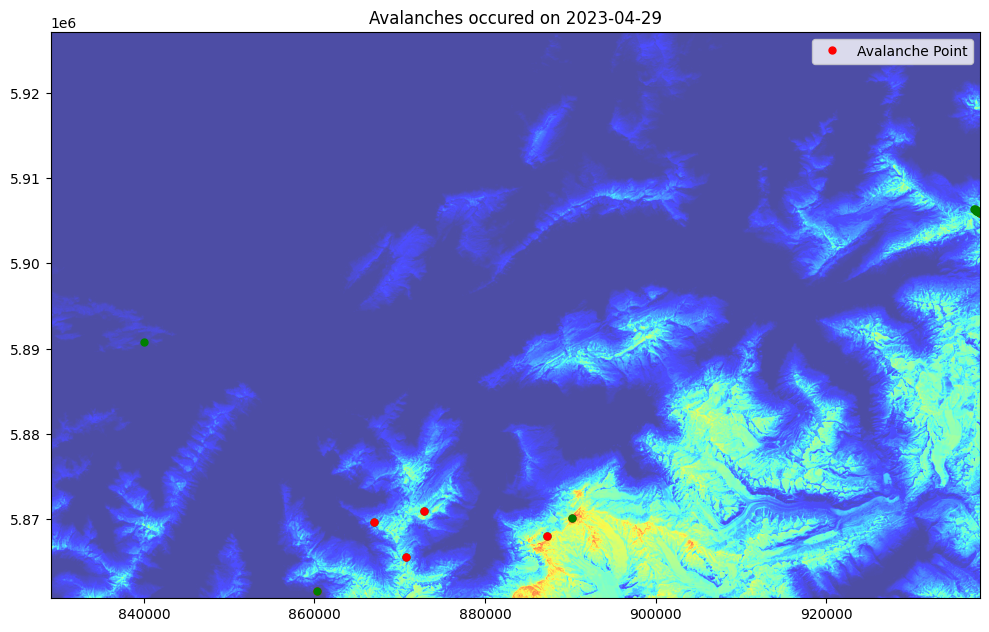

In [28]:
###plot avalanches on day 2023-04-01 from new_df
new_df = pd.read_csv('avalanche+sat+depth+weather_sequential.csv')
import matplotlib.pyplot as plt
from rasterio.plot import show  # Correct way to plot raster data
import rasterio
from pyproj import Transformer

tif_path = tif_path_from_date('2023-04-29')
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
date = '2023-04-29'

with rasterio.open(tif_path) as src:
    band = src.read(1)
    transform = src.transform  # Affine transform for pixel <-> world coords

    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Plot the raster correctly using rasterio.plot.show
    show(band, transform=transform, cmap='jet', ax=ax, alpha=0.7)

    ax.set_title('Avalanches occured on ' + date)   

    
    # Plot avalanche points
    for _, row in new_df.iterrows():
        if date in row['trigger_date_time']:
            lon = row['lon']
            lat = row['lat']
            is_avalanche = row['Avalanche Event']

            if is_avalanche == 1:

                x_3857, y_3857 = transformer.transform(lon, lat)

                ax.plot(x_3857, y_3857, 'ro', markersize=5, label='Avalanche Point')
            else:
                x_3857, y_3857 = transformer.transform(lon, lat)

                ax.plot(x_3857, y_3857, 'go', markersize=5, label='Random Point')

    # Optional: show legend only once
    handles, labels = ax.get_legend_handles_labels()
    if handles:
        ax.legend([handles[0]], [labels[0]], loc='upper right')
        

plt.tight_layout()
plt.show()


In [7]:
### ADD ELEVATION PROFILE 

Coordinate is out of bounds.


In [29]:
###WEATHER STATION DATA MAPPING 
file_path = '../Data/full_dataset.csv'

import pandas as pd

df = pd.read_csv(file_path)

# Extract the unique station codes along with their lon and lat
unique_stations = df[['station_code', 'lon', 'lat']].drop_duplicates()

unique_stations.dropna(inplace=True)
print(unique_stations)

from pyproj import Proj, transform


epsg4326 = Proj(init="epsg:4326")
epsg3857 = Proj(init="epsg:3857")

# Define the bounding box in EPSG:3857
bounding_box = {
    'left': 829059.4892686082,
    'bottom': 5860743.433705239,
    'right': 938039.4892686082,
    'top': 5927163.433705239
}
df = unique_stations
# Function to convert lon/lat to EPSG:3857
def lonlat_to_epsg3857(lon, lat):
    x, y = transform(epsg4326, epsg3857, lon, lat)
    return x, y

# Filter stations within the bounding box
stations_in_bbox = []

for index, row in df.iterrows():
    lon, lat = row['lon'], row['lat']
    
    # Convert to EPSG:3857
    x, y = lonlat_to_epsg3857(lon, lat)
    
    # Check if the station is within the bounding box
    if bounding_box['left'] <= x <= bounding_box['right'] and bounding_box['bottom'] <= y <= bounding_box['top']:
        stations_in_bbox.append(row['station_code'])

# Output the stations that are within the bounding box
print("Stations within the bounding box (EPSG:3857):")
print(stations_in_bbox)


      station_code       lon        lat
3653          DIA2  7.241038  46.315405
3696          GLA2  9.037583  46.996629
3825          TUJ3  8.740224  46.647032
3913          OBW2  8.315956  46.545222
3957          URS2  8.513860  46.586787
...            ...       ...        ...
11082         KES2  9.898140  46.621285
11122         LAG2  9.744580  46.451358
11162         FUL2  7.089661  46.194685
11163         ILI2  6.827797  46.191356
11203         FIR2  8.064403  46.668777

[95 rows x 3 columns]


/Users/ilyayakushevskiy/.pyenv/versions/3.12.0/lib/python3.12/site-packages/pyproj/crs/crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
/Users/ilyayakushevskiy/.pyenv/versions/3.12.0/lib/python3.12/site-packages/pyproj/crs/crs.py:143: FutureWarning: '+init=<authority>:<code>' syntax is deprecated. '<authority>:<code>' is the preferred initialization method. When making the change, be mindful of axis order changes: https://pyproj4.github.io/pyproj/stable/gotchas.html#axis-order-changes-in-proj-6
  in_crs_string = _prepare_from_proj_string(in_crs_string)
/var/folders/lj/yyssz_p12f50nl5zkgxpqy5h0000gn/T/ipykernel_74669/1535156463.py:30: FutureWarning: This function is deprecated. See: https://pyproj4.github

Stations within the bounding box (EPSG:3857):
['OBW2', 'GAD2', 'TIT2', 'FAE2', 'GUT2', 'OTT2', 'ROA2', 'SCH2', 'MAE2', 'SCB2', 'OBW3', 'TIT2', 'GAD2', 'OBW3', 'GUT2', 'ROA2', 'FIR2']


In [36]:
# import matplotlib.pyplot as plt

# fig, axes = plt.subplots(4, 3, figsize=(12, 8))  

# for i in range(12):
#     ax = axes[i // 3, i % 3]
#     ax.imshow(tif_files[i], cmap='jet') 
#     ax.set_title(f"Image {i}")
#     ax.axis('off')

# plt.tight_layout()
# plt.show()


In [47]:
### WEATHER STATION DATA



# Load station metadata
stations_df = pd.read_csv('../Data/Sat-Data/meta_stations.csv', sep=';')

# Transformer from EPSG:4326 to EPSG:3857
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)

# Transform and filter
def is_in_bounds(lon, lat):
    x, y = transformer.transform(lon, lat)
    return (829059.4892686082 <= x <= 938039.4892686082) and (5860743.433705239 <= y <= 5927163.433705239)

stations_df['in_bounds'] = stations_df.apply(lambda row: is_in_bounds(row['station_coordinates_wgs84_lon'], row['station_coordinates_wgs84_lat']), axis=1)
stations_in_bounds = stations_df[stations_df['in_bounds']]

print(stations_in_bounds["station_abbr"])


23     BRZ
52     ENG
56     FLU
58     FRU
61     GIH
69     GRH
79     INT
80     JUN
94     MER
143    THU
144    TIT
146    ULR
Name: station_abbr, dtype: object


In [48]:
stations = {} 

for _, row in stations_in_bounds.iterrows():
    station_code = row['station_abbr']
    lon = row['station_coordinates_wgs84_lon']
    lat = row['station_coordinates_wgs84_lat']

    # Convert to EPSG:3857
    #x_3857, y_3857 = transformer.transform(lon, lat)
    station_code_small_literals = station_code.lower()
    station_path = f'../Data/Sat-Data/meteoswiss_data/ogd-smn_{station_code_small_literals}_h_historical_2020-2029.csv'
    stations[station_code] = (lon, lat, station_path) 



In [49]:
###MATCH DATA FROM CLOTHEST STATION (1-5KM range )
import numpy as np 
brz_data = pd.read_csv('../Data/Sat-Data/meteoswiss_data/ogd-smn_brz_h_historical_2020-2029.csv', sep=';')
new_df = new_df.copy()


new_df['closest_station'] = None
distances = 0
# Iterate over each avalanche record
for i, row in new_df.iterrows():
    lon_av = row['lon']
    lat_av = row['lat']

    # Track the closest station: (station_code, lon, lat, distance)
    closest_station = (None, None, None, float('inf'))

    for station_code, (lon_st, lat_st, station_path) in stations.items():
        distance = np.sqrt((lon_av - lon_st)**2 + (lat_av - lat_st)**2) * 111139  # approx meters
        
        if distance < closest_station[3]:
            closest_station = (station_code, lon_st, lat_st, distance)

    closest_station_code = closest_station[0]
    distances += closest_station[3]
    
    
    new_df.at[i, 'closest_station'] = closest_station_code

   # print(f"Closest station for avalanche {row['avalanche_id']} is {closest_station_code} with distance {closest_station[3]:.2f} m")

avg_distance = distances / len(new_df)
# Display results
print(f"Average distance to closest station: {avg_distance:.2f} m")
new_df.head()


Average distance to closest station: 4325.79 m


,avalanche_id,location,trigger_date_time,trigger_date_time_accuracy_code,trigger_type,avalanche_type,avalanche_size,avalanche_moisture,start_zone_aspect,snow_depth_sat,lat,lon,Avalanche Event,closest_station
0,20077a30-ec16-11ed-aa20-6507e99101f4,8.022203 46.505884,2023-05-06 14:00:00.000 +0200,0,PERSON,SLAB,2,WET,E,90,46.505884,8.022203,1,JUN
1,8500f990-d7a6-11ed-a8d1-4961cd70d9e1,8.209308 46.504515,2023-04-12 12:00:00+02:00,7,NATURAL,SLAB,4,WET,S,232,46.504515,8.209308,0,ULR
2,6e6f00b6-dfe0-4527-9b3f-7c45ffdf4fee,8.379219 46.783826,2023-04-01 07:00:00.000 +0200,4,EXPLOSIVE,SLAB,2,DRY,N,114,46.783826,8.379219,1,TIT
3,792e43cf-e040-4ad1-98dd-47672e4855cd,8.426192 46.777884,2023-04-13 07:00:00.000 +0200,0,EXPLOSIVE,SLAB,2,DRY,NE,161,46.777884,8.426192,1,TIT
4,bc76da5f-d990-4bb2-a099-1ab0703da0a4,8.422538 46.779775,2023-05-03 07:30:00+02:00,4,EXPLOSIVE,SLAB,2,DRY,N,107,46.779775,8.422538,0,TIT


In [50]:
### ADD ALL WEATHER STATION DATA TO AVALANCHE DATA

for i, row in new_df.iterrows():
    station_code = row['closest_station']
    station_path = stations[station_code][2]
    
    # Load the station data
    station_data = pd.read_csv(station_path, sep=';')

    # Try converting to datetime
    try:
        station_data['reference_timestamp'] = pd.to_datetime(
            station_data['reference_timestamp'], 
            format="%d.%m.%Y %H:%M", 
            errors='coerce'
        )
    except Exception as e:
        print(f"Date parsing failed for station {station_code}: {e}")
        continue

    # Drop rows where timestamp parsing failed
    station_data = station_data.dropna(subset=['reference_timestamp'])

    # Confirm it's datetime dtype
    if not pd.api.types.is_datetime64_any_dtype(station_data['reference_timestamp']):
        print(f"reference_timestamp is not datetime for station {station_code}")
        continue

    # Make tz-naive (in case it’s tz-aware)
    station_data['reference_timestamp'] = station_data['reference_timestamp'].dt.tz_localize(None)

    # Avalanche time
    avalanche_dt = pd.to_datetime(row['trigger_date_time'], errors='coerce')
    if pd.notna(avalanche_dt) and avalanche_dt.tzinfo is not None:
        avalanche_dt = avalanche_dt.tz_localize(None)

    if pd.isna(avalanche_dt) or station_data.empty:
        print(f"Skipping row {i} due to date parse error or empty station data")
        continue

    # Compute time differences
    time_diffs = np.abs((station_data['reference_timestamp'] - avalanche_dt).dt.total_seconds())
    closest_idx = time_diffs.idxmin()
    closest_row = station_data.loc[closest_idx]

    # Copy data to avalanche row
    for col in station_data.columns:
        if col != 'reference_timestamp':
            new_df.at[i, col] = closest_row[col]

    



In [155]:
new_df.head()

,avalanche_id,location,trigger_date_time,trigger_date_time_accuracy_code,trigger_type,avalanche_type,avalanche_size,avalanche_moisture,start_zone_aspect,snow_depth_sat,...,fve010h0,rre150h0,htoauths,gre000h0,oli000h0,olo000h0,osr000h0,ods000h0,sre000h0,erefaoh0
0,f7fca170-d124-11ed-9f3d-c1122c0370be,8.243319 46.765333,2023-04-04 12:00:00+02:00,10,NATURAL,SLAB,3,WET,SW,0,...,NaN,0.0,NaN,847.0,NaN,NaN,NaN,134.0,60.0,0.327
1,1a787419-5802-4808-a192-fbe672afe523,8.389757 46.787324,2023-04-19 08:30:00+02:00,4,EXPLOSIVE,LOOSE_SNOW,2,DRY,N,0,...,NaN,0.0,0.0,545.0,295.0,NaN,NaN,NaN,55.0,0.227
2,20077a30-ec16-11ed-aa20-6507e99101f4,8.022203 46.505884,2023-05-08 14:00:00+02:00,0,PERSON,SLAB,2,WET,E,164,...,NaN,NaN,NaN,790.0,294.0,NaN,NaN,NaN,2.0,0.277
4,a8219770-e77f-11ed-991c-c3bbd7ca6c9a,7.788493 46.554381,2023-04-29 15:11:00.000 +0200,0,NATURAL,SLAB,3,WET,NW,102,...,NaN,0.0,NaN,318.0,350.0,NaN,NaN,288.0,0.0,NaN
5,c8a8b700-feb1-11ed-b35a-bf420b8ac344,8.01247 46.561817,2023-05-31 12:00:00+02:00,6,PERSON,SLAB,2,DRY,SE,287,...,NaN,NaN,NaN,705.0,289.0,NaN,NaN,NaN,1.0,0.218


In [51]:
new_df.to_csv('avalanche+sat+depth+weather_sequential.csv', index=False)

In [69]:
#how much non avalanche days should we impute? 
df3  = pd.read_csv('../Data/dataset1.csv')

no_avalanches = 0 
avalanche_day = 0

ava_days = df3["avalancheDay1"].sum()
no_avalanches = df3.shape[0] - avalanche_day
print(f"Number of avalanches: {ava_days/(no_avalanches+ava_days)} days")

Number of avalanches: 0.09958097116095638 days


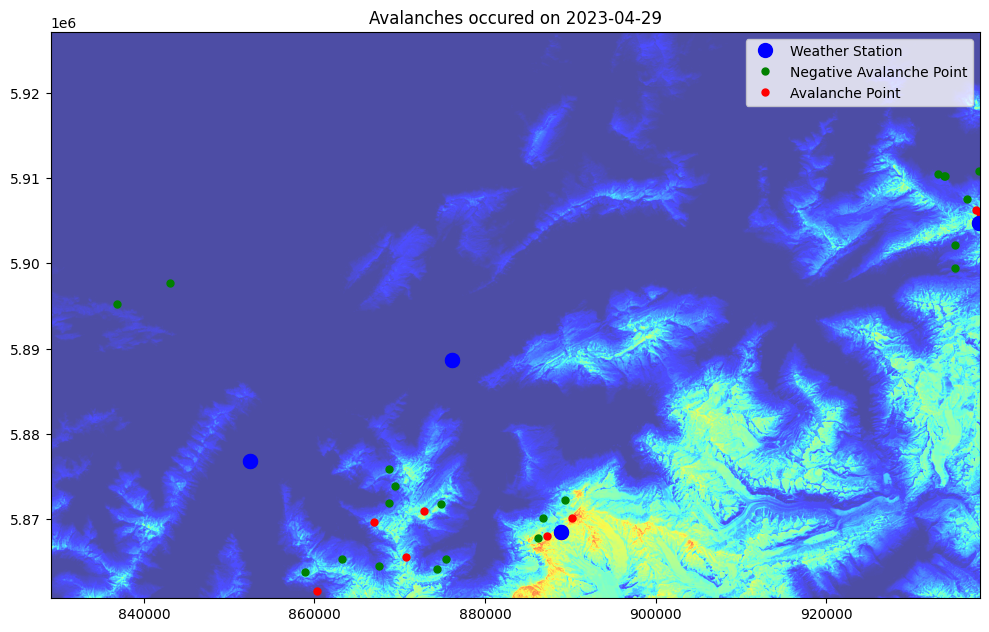

In [19]:
### Visulaze stations on top of the map

###plot avalanches on day 2023-04-01 from new_df
new_df = pd.read_csv('avalanche_sat+weather_all.csv')
import matplotlib.pyplot as plt
from rasterio.plot import show  # Correct way to plot raster data
import rasterio
from pyproj import Transformer

tif_path = tif_path_from_date('2023-04-29')
transformer = Transformer.from_crs("EPSG:4326", "EPSG:3857", always_xy=True)
date = '2023-04-29'

with rasterio.open(tif_path) as src:
    band = src.read(1)
    transform = src.transform  # Affine transform for pixel <-> world coords

    fig, ax = plt.subplots(figsize=(10, 10))
    
    # Plot the raster correctly using rasterio.plot.show
    show(band, transform=transform, cmap='jet', ax=ax, alpha=0.7)

    ax.set_title('Avalanches occured on ' + date)   

    
    # Plot avalanche points
    for _, row in new_df.iterrows():
        if date in row['trigger_date_time']:
            lon = row['lon']
            lat = row['lat']
            station_code = row['closest_station']
            # Get station coordinates
            station_lon = stations[station_code][0]
            station_lat = stations[station_code][1]
            # Convert to EPSG:3857
            station_x_3857, station_y_3857 = transformer.transform(station_lon, station_lat)
            is_avalanche = row['Avalanche Event']

            if is_avalanche == 1:

                x_3857, y_3857 = transformer.transform(lon, lat)

                ax.plot(x_3857, y_3857, 'ro', markersize=5, label='Avalanche Point')
                ax.plot(station_x_3857, station_y_3857, 'bo', markersize=10, label='Weather Station')


            else:
                x_3857, y_3857 = transformer.transform(lon, lat)

                ax.plot(x_3857, y_3857, 'go', markersize=5, label='Negative Avalanche Point')

    # Optional: display all labels on the legend
    handles, labels = ax.get_legend_handles_labels()
    unique_labels = set(labels)
    unique_handles = [handles[labels.index(label)] for label in unique_labels]
    ax.legend(unique_handles, unique_labels, loc='upper right')

        

plt.tight_layout()
plt.show()


Elevation at (46.9481,7.4474): 551.0 meters


In [ ]:
#FIND Random points on the map and impute them to our dataset  (90%) with non avalanche days